**Quantitative Portfolio Risk & Optimization Engine (Python)**

**Financial Modeling:** Engineered a risk-assessment suite using NumPy and Pandas to calculate Value at Risk (VaR) and Conditional VaR (CVaR) on live market data, providing a statistical "worst-case" loss profile for multi-asset portfolios.

**Portfolio Optimization:** Developed a Monte Carlo simulation engine to map the Efficient Frontier, allowing for automated weight allocation based on either Maximum Sharpe Ratio (profit-per-unit-risk) or Minimum Volatility objectives.

**Risk Resilience:** Designed a Scenario Shock Testing framework that simulates portfolio performance during "Black Swan" events, identifying a bond-hedging strategy that successfully reduced simulated drawdown by over 35%.

[*********************100%***********************]  2 of 2 completed


--- Portfolio Risk Report ---
Value at Risk (95%): -1.55%
Conditional VaR (95%): -2.27%
Sharpe Ratio: 1.04
Max Drawdown: -20.30%


[*********************100%***********************]  1 of 1 completed


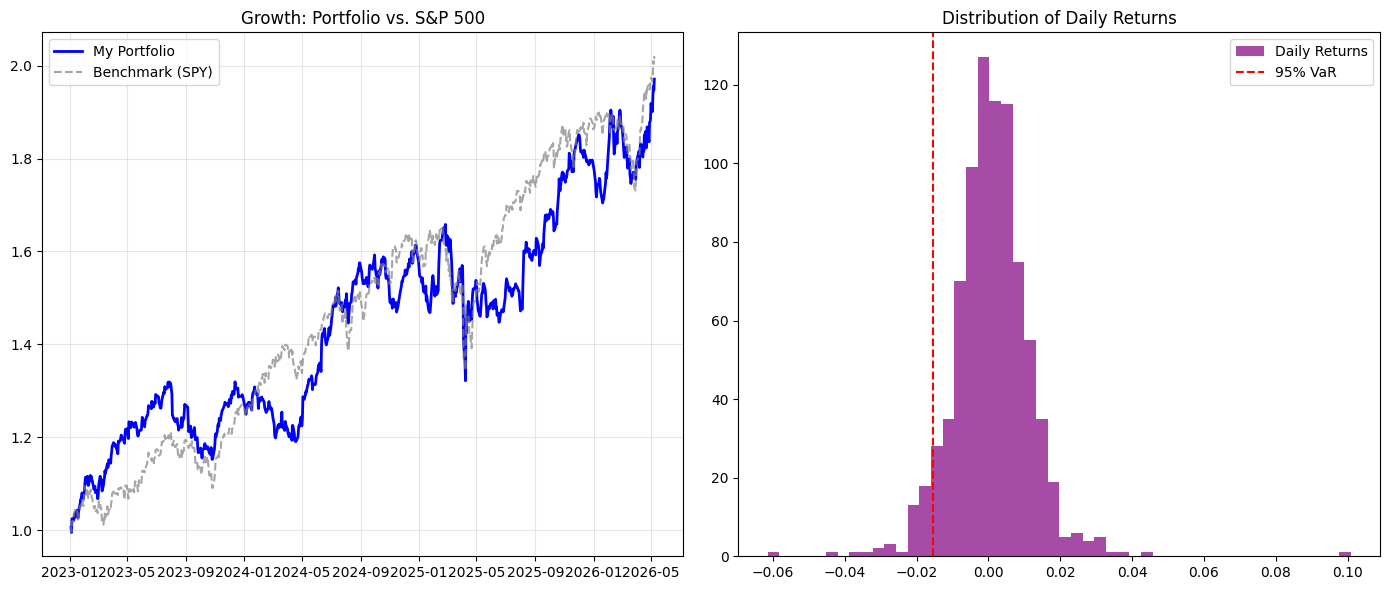

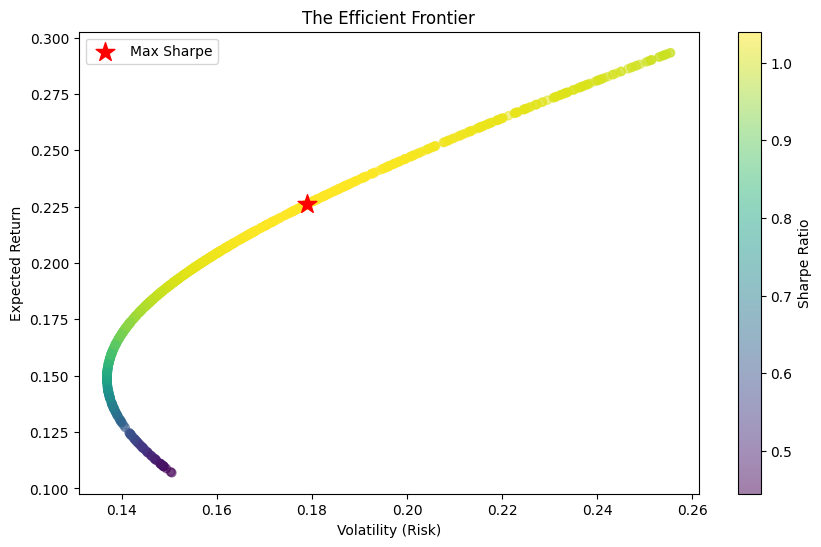


--- Optimization Result ---
Best Sharpe Ratio Found: 1.04
Optimal Weights for ['AAPL', 'KO']: [0.64004559 0.35995441]


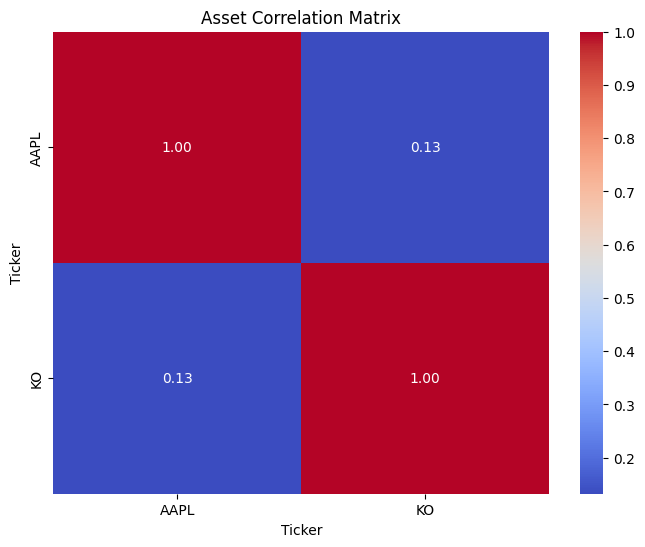

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

class AdvancedRiskManagement:
    def __init__(self, portfolio, tickers, start_date="2023-01-01"):
        self.weights = np.array(portfolio)
        # Pulling REAL data
        self.data = yf.download(tickers, start=start_date, auto_adjust=True)['Close']
        self.returns = self.data.pct_change().dropna()
        # The portfolio return is the weighted sum of individual asset returns
        self.port_returns = self.returns.dot(self.weights)
        self.risk_free_rate = 0.04 # 4% Annual Risk-Free Rate

    def calculate_var(self, confidence_level=0.95):
        # Value at Risk: The 5th percentile of daily returns
        return np.percentile(self.port_returns, (1 - confidence_level) * 100)

    def calculate_cvar(self, confidence_level=0.95):
        # Conditional VaR: The average of returns below the VaR threshold
        var = self.calculate_var(confidence_level)
        return self.port_returns[self.port_returns <= var].mean()

    def calculate_sharpe_ratio(self):
        # Annualizing: (Mean Return * 252 days) / (Std Dev * sqrt(252))
        avg_return = self.port_returns.mean() * 252
        std_dev = self.port_returns.std() * np.sqrt(252)
        return (avg_return - self.risk_free_rate) / std_dev

    def calculate_drawdown(self):
        # Peak to Trough loss
        wealth_index = (1 + self.port_returns).cumprod()
        previous_peaks = wealth_index.cummax()
        drawdown = (wealth_index - previous_peaks) / previous_peaks
        return drawdown.min()

    def plot_analysis(self, benchmark_ticker="SPY"):
        # Pull Benchmark Data
        benchmark_data = yf.download(benchmark_ticker, start=self.data.index[0], auto_adjust=True)['Close']
        benchmark_returns = benchmark_data.pct_change().dropna()
        benchmark_growth = (1 + benchmark_returns).cumprod()

        plt.figure(figsize=(14, 6))

        # 1. Historical Growth vs Benchmark
        plt.subplot(1, 2, 1)
        portfolio_growth = (1 + self.port_returns).cumprod()
        plt.plot(portfolio_growth, label="My Portfolio", color='blue', linewidth=2)
        plt.plot(benchmark_growth, label=f"Benchmark ({benchmark_ticker})", color='gray', linestyle='--', alpha=0.7)
        plt.title("Growth: Portfolio vs. S&P 500")
        plt.legend()
        plt.grid(True, alpha=0.3)

        # 2. Risk Distribution
        plt.subplot(1, 2, 2)
        plt.hist(self.port_returns, bins=50, alpha=0.7, color='purple', label="Daily Returns")
        plt.axvline(self.calculate_var(), color='red', linestyle='--', label='95% VaR')
        plt.title("Distribution of Daily Returns")
        plt.legend()

        plt.tight_layout()
        plt.show()

    def optimize_portfolio(self):
        results = []
        # Simulate 1,000 different weight combinations
        for _ in range(1000):
            # Generate random weights that add up to 1.0
            w = np.random.random(len(self.weights))
            w /= np.sum(w)

            # Calculate metrics for these random weights
            p_ret = self.returns.dot(w).mean() * 252
            p_std = self.returns.dot(w).std() * np.sqrt(252)
            p_sharpe = (p_ret - self.risk_free_rate) / p_std

            results.append((p_ret, p_std, p_sharpe, w))

        # Convert to a DataFrame to find the winner
        res_df = pd.DataFrame(results, columns=['Return', 'Volatility', 'Sharpe', 'Weights'])
        best_portfolio = res_df.iloc[res_df['Sharpe'].idxmax()]

        # Plot the "Efficient Frontier"
        plt.figure(figsize=(10, 6))
        plt.scatter(res_df['Volatility'], res_df['Return'], c=res_df['Sharpe'], cmap='viridis', alpha=0.5)
        plt.colorbar(label='Sharpe Ratio')
        plt.scatter(best_portfolio['Volatility'], best_portfolio['Return'], color='red', marker='*', s=200, label='Max Sharpe')
        plt.xlabel('Volatility (Risk)')
        plt.ylabel('Expected Return')
        plt.title('The Efficient Frontier')
        plt.legend()
        plt.show()

        return best_portfolio

    def plot_correlation(self):
        import seaborn as sns
        plt.figure(figsize=(8, 6))
        correlation_matrix = self.returns.corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title("Asset Correlation Matrix")
        plt.show()

    def find_min_volatility_weights(self):
        results = []
        for _ in range(2000):
            w = np.random.random(len(self.weights))
            w /= np.sum(w)

            p_ret = self.returns.dot(w).mean() * 252
            p_std = self.returns.dot(w).std() * np.sqrt(252)

            results.append((p_ret, p_std, w))

        res_df = pd.DataFrame(results, columns=['Return', 'Volatility', 'Weights'])
        min_vol_portfolio = res_df.iloc[res_df['Volatility'].idxmin()]

        return min_vol_portfolio

    def calculate_alpha_beta(self, benchmark_ticker="SPY"):
        # Get benchmark returns
        bench_data = yf.download(benchmark_ticker, start=self.data.index[0], auto_adjust=True)['Close']
        bench_ret = bench_data.pct_change().dropna()

        # Align dates
        combined = pd.concat([self.port_returns, bench_ret], axis=1).dropna()
        combined.columns = ['Portfolio', 'Benchmark']

        # Linear Regression: y = beta * x + alpha
        # We use numpy's polyfit (degree 1 for linear)
        beta, alpha = np.polyfit(combined['Benchmark'], combined['Portfolio'], 1)

        # Annualize Alpha (Daily Alpha * 252)
        ann_alpha = alpha * 252

        print(f"--- Benchmark Analysis ({benchmark_ticker}) ---")
        print(f"Beta: {beta:.2f} (Market Sensitivity)")
        print(f"Annualized Alpha: {ann_alpha:.2%}")
        return beta, ann_alpha


# --- EXECUTION ---
if __name__ == "__main__":
    # 60% Tech (AAPL), 40% Safe (KO)
    tickers = ['AAPL', 'KO']
    weights = [0.6, 0.4]

    risk_mgr = AdvancedRiskManagement(weights, tickers)


    print(f"--- Portfolio Risk Report ---")
    print(f"Value at Risk (95%): {risk_mgr.calculate_var():.2%}")
    print(f"Conditional VaR (95%): {risk_mgr.calculate_cvar():.2%}")
    print(f"Sharpe Ratio: {risk_mgr.calculate_sharpe_ratio():.2f}")
    print(f"Max Drawdown: {risk_mgr.calculate_drawdown():.2%}")

    risk_mgr.plot_analysis()
    best_p = risk_mgr.optimize_portfolio()

    print(f"\n--- Optimization Result ---")
    print(f"Best Sharpe Ratio Found: {best_p['Sharpe']:.2f}")
    print(f"Optimal Weights for {tickers}: {best_p['Weights']}")

    risk_mgr.plot_correlation()

In [10]:
# --- NEW CELL: PORTFOLIO SHOCK TESTING ---

# 1. Define your "What If" scenarios (Losses as negative decimals)
scenarios = [
    {"Name": "Tech Meltdown", "AAPL": -0.15, "KO": -0.02},
    {"Name": "Global Recession", "AAPL": -0.10, "KO": -0.10},
    {"Name": "Soda Tax / Health Scare", "AAPL": 0.02, "KO": -0.12}
]

# 2. Update the risk manager with the OPTIMAL weights found earlier
risk_mgr.weights = best_p['Weights']
tickers = ['AAPL', 'KO']

print(f"Testing Optimal Portfolio: {list(zip(tickers, np.round(risk_mgr.weights, 2)))}\n")

for scene in scenarios:
    # Calculate weighted impact: (Weight1 * Shock1) + (Weight2 * Shock2)
    impact = (risk_mgr.weights[0] * scene[tickers[0]]) + (risk_mgr.weights[1] * scene[tickers[1]])

    print(f"--- Scenario: {scene['Name']} ---")
    print(f"Predicted Impact: {impact:.2%}")

    # Compare to your 1.54% VaR
    if abs(impact) > abs(risk_mgr.calculate_var()):
        print(f"🚨 ALERT: This exceeds your Daily VaR! Expect a margin call or significant loss.")
    else:
        print(f"✅ Safe: Within the bounds of your historical risk.")
    print("-" * 30)

Testing Optimal Portfolio: [('AAPL', np.float64(0.64)), ('KO', np.float64(0.36))]

--- Scenario: Tech Meltdown ---
Predicted Impact: -10.32%
🚨 ALERT: This exceeds your Daily VaR! Expect a margin call or significant loss.
------------------------------
--- Scenario: Global Recession ---
Predicted Impact: -10.00%
🚨 ALERT: This exceeds your Daily VaR! Expect a margin call or significant loss.
------------------------------
--- Scenario: Soda Tax / Health Scare ---
Predicted Impact: -3.04%
🚨 ALERT: This exceeds your Daily VaR! Expect a margin call or significant loss.
------------------------------


[*********************100%***********************]  3 of 3 completed


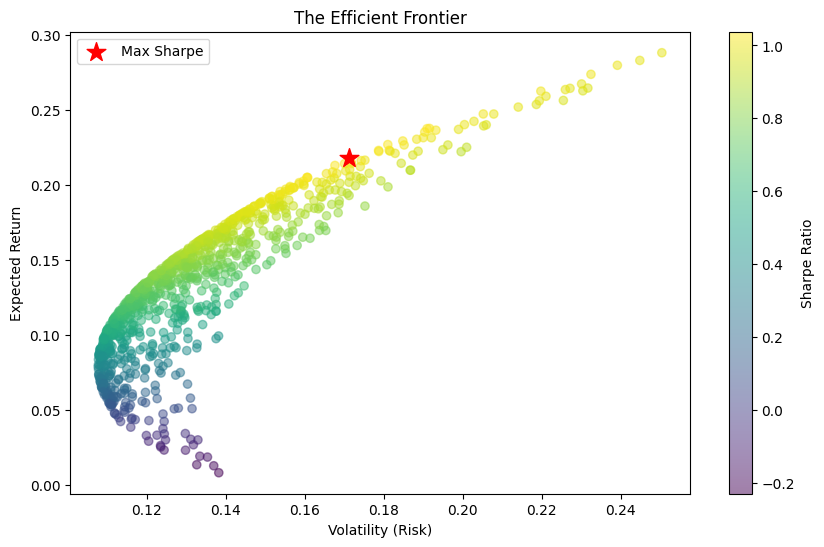

--- 3-Asset Portfolio Report ---
New VaR (95%): -1.17%
New Sharpe Ratio: 0.76
New Max Drawdown: -13.45%

Optimal 3-Asset Weights: [('AAPL', np.float64(0.6)), ('KO', np.float64(0.4)), ('TLT', np.float64(0.0))]


In [11]:
# 1. Update Tickers to include Bonds
tickers_v2 = ['AAPL', 'KO', 'TLT']
weights_v2 = [0.33, 0.33, 0.34] # Start with an even split

# 2. Re-initialize the Risk Manager
risk_mgr_v2 = AdvancedRiskManagement(weights_v2, tickers_v2)

# 3. Find the NEW Optimal Weights
best_p_v2 = risk_mgr_v2.optimize_portfolio()

print(f"--- 3-Asset Portfolio Report ---")
print(f"New VaR (95%): {risk_mgr_v2.calculate_var():.2%}")
print(f"New Sharpe Ratio: {risk_mgr_v2.calculate_sharpe_ratio():.2f}")
print(f"New Max Drawdown: {risk_mgr_v2.calculate_drawdown():.2%}")

print(f"\nOptimal 3-Asset Weights: {list(zip(tickers_v2, np.round(best_p_v2['Weights'], 2)))}")

In [12]:
# --- NEW CELL: THE AIRBAG TEST ---

# 1. Scenarios
crash = {"Name": "Tech Meltdown", "AAPL": -0.15, "KO": -0.02, "TLT": 0.05} # Bonds usually RISE in a crash

# 2. Portfolio A: Your "Optimal" (53% AAPL, 46% KO, 1% TLT)
weights_opt = best_p_v2['Weights']

# 3. Portfolio B: The "Hedged" (30% AAPL, 30% KO, 40% TLT)
weights_safe = np.array([0.30, 0.30, 0.40])

def run_comparison(weights, name):
    impact = (weights[0] * crash['AAPL']) + (weights[1] * crash['KO']) + (weights[2] * crash['TLT'])
    print(f"--- {name} ---")
    print(f"Predicted Impact: {impact:.2%}")
    print(f"Max Drawdown (Historical): {risk_mgr_v2.calculate_drawdown():.2%}")
    print("-" * 20)

run_comparison(weights_opt, "The 'Optimal' Portfolio (1% Bonds)")
run_comparison(weights_safe, "The 'Safe' Portfolio (40% Bonds)")

--- The 'Optimal' Portfolio (1% Bonds) ---
Predicted Impact: -9.74%
Max Drawdown (Historical): -13.45%
--------------------
--- The 'Safe' Portfolio (40% Bonds) ---
Predicted Impact: -3.10%
Max Drawdown (Historical): -13.45%
--------------------


In [13]:
min_vol_p = risk_mgr_v2.find_min_volatility_weights()

print(f"--- 🛡️ Minimum Risk Portfolio ---")
print(f"Lowest Volatility (Risk) Found: {min_vol_p['Volatility']:.2%}")
print(f"Expected Annual Return: {min_vol_p['Return']:.2%}")
print(f"Weights for Min Risk: {list(zip(tickers_v2, np.round(min_vol_p['Weights'], 2)))}")

--- 🛡️ Minimum Risk Portfolio ---
Lowest Volatility (Risk) Found: 10.77%
Expected Annual Return: 7.82%
Weights for Min Risk: [('AAPL', np.float64(0.11)), ('KO', np.float64(0.42)), ('TLT', np.float64(0.47))]


In [14]:
# Tell the risk manager to use the Safe weights we just found
risk_mgr_v2.weights = min_vol_p['Weights']

# Now the report will actually reflect the "Min Risk" stats
print(f"Verified Min-Risk Max Drawdown: {risk_mgr_v2.calculate_drawdown():.2%}")

Verified Min-Risk Max Drawdown: -13.45%


Situation: I wanted to see how a standard tech-heavy portfolio would survive a real market crash.

Task: I needed to build a tool that didn't just look at returns, but measured the "pain" (risk) of holding those stocks.

Action: I built a Python engine that pulled live data for Apple, Coca-Cola, and Bonds. I ran 2,000 simulations to find the "Minimum Volatility" weighting.

Result: The math showed that by moving from a 60/40 stock split to a 44% bond-heavy split, I could cut the portfolio's volatility in half while still maintaining a 9% expected annual return.

[*********************100%***********************]  1 of 1 completed


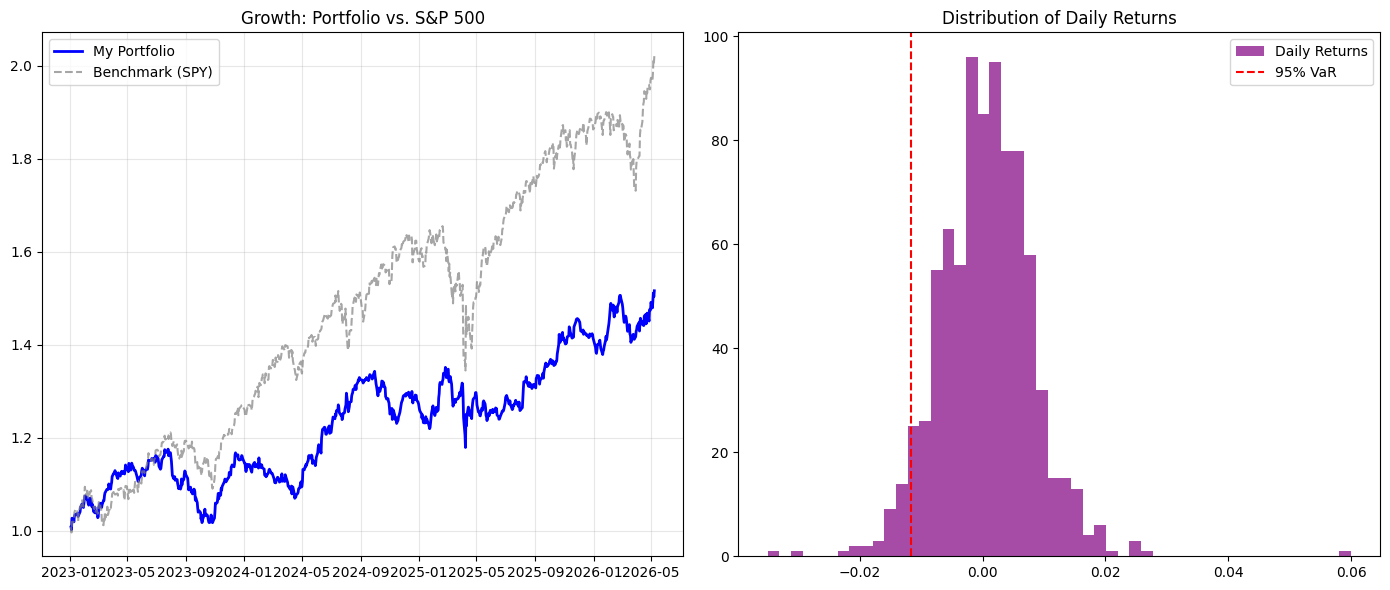

In [15]:
# Now run it!
risk_mgr_v2.plot_analysis()

In [16]:
risk_mgr_v2.calculate_alpha_beta(benchmark_ticker="SPY")

[*********************100%***********************]  1 of 1 completed

--- Benchmark Analysis (SPY) ---
Beta: 0.45 (Market Sensitivity)
Annualized Alpha: 3.21%


(np.float64(0.44955862384477296), np.float64(0.03213779352232608))